<a href="https://colab.research.google.com/github/David-Junior/Undergrad-Lab-Data-Analysis/blob/main/FMM3_232_Fluids_II_Venturimeter_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Experimental Data
h1 = np.array([61.5, 61.0, 60.6, 60.1, 59.5, 58.4, 57.7, 56.8, 56.5, 55.8, 54.5, 53.8])/100
h2 = np.array([35.5, 36.0, 36.3, 36.7, 37.5, 38.6, 39.3, 40.2, 40.6, 41.2, 42.5, 43.3])/100
D1 = np.array([3.4, 8.8, 14.3, 16.1, 23.8, 28.2, 4.1, 7.1, 9.2, 11.7, 14.1, 16.4])/100
D2 = np.array([8.8, 14.3, 16.1, 23.8, 28.2, 32.2, 7.1, 9.2, 11.7, 14.1, 16.4, 18.6])/100
t = np.array([16.72, 16.85, 15.13, 15.14, 14.57, 14.83, 10.93, 8.89, 10.02, 9.85, 10.62, 10.85])

d1 = 26/1000 #m
d2 = 13/1000 #m
D_tank = 38/100 #m
A1 = np.pi*d1**2/4 #m^2
A2 = np.pi*d2**2/4 #m^2
A_tank = np.pi*D_tank**2/4 #m^2
SG = 2.96
g = 9.81

In [ ]:
# Analysis
hm = h1 - h2
h = hm*(SG-1)

Vol = A_tank*(D2-D1)
Q = Vol/t

log_Q = np.log(Q)
log_h = np.log(h)

In [ ]:
DF = pd.DataFrame({
    'h1': h1,
    'h2': h2,
    'hm': hm,
    'h': h,
    'D1': D1,
    'D2': D2,
    'Vol': Vol,
    'Q': Q,
    'log_Q': log_Q,
    'log_h': log_h
})
DF

,h1,h2,hm,h,D1,D2,Vol,Q,log_Q,log_h
0,0.615,0.355,0.260,0.50960,0.034,0.088,0.006124,0.000366,-7.912109,-0.674129
1,0.610,0.360,0.250,0.49000,0.088,0.143,0.006238,0.000370,-7.901505,-0.713350
2,0.606,0.363,0.243,0.47628,0.143,0.161,0.002041,0.000135,-8.910796,-0.741749
3,0.601,0.367,0.234,0.45864,0.161,0.238,0.008733,0.000577,-7.458023,-0.779490
4,0.595,0.375,0.220,0.43120,0.238,0.282,0.004990,0.000342,-7.979263,-0.841183
5,0.584,0.386,0.198,0.38808,0.282,0.322,0.004536,0.000306,-8.092261,-0.946544
6,0.577,0.393,0.184,0.36064,0.041,0.071,0.003402,0.000311,-8.074802,-1.019875
7,0.568,0.402,0.166,0.32536,0.071,0.092,0.002382,0.000268,-8.224892,-1.122823
8,0.565,0.406,0.159,0.31164,0.092,0.117,0.002835,0.000283,-8.170195,-1.165907
9,0.558,0.412,0.146,0.28616,0.117,0.141,0.002722,0.000276,-8.193905,-1.251204


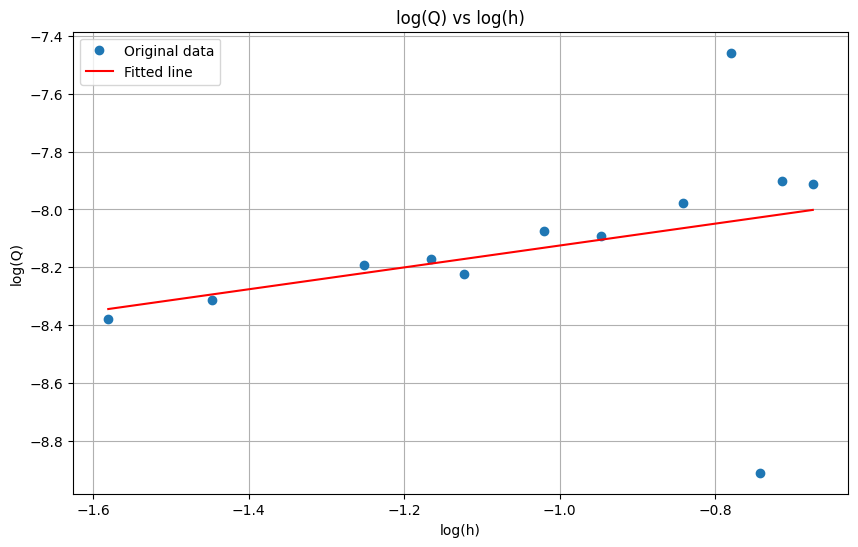

Gradient (slope): 0.3781
Y-intercept: -7.7468


In [ ]:
import scipy.stats

# Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(log_h, log_Q, 'o', label='Original data')

# Finding the line of best fit
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(log_h, log_Q)

# Plotting the line of best fit
plt.plot(log_h, intercept + slope * log_h, 'r', label='Fitted line')

plt.xlabel('log(h)')
plt.ylabel('log(Q)')
plt.title('log(Q) vs log(h)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Gradient (slope): {slope:.4f}")
print(f"Y-intercept: {intercept:.4f}")

In [ ]:
n = slope
Cd = np.exp(intercept)*np.sqrt((A1/A2)**2-1)/(A1*np.sqrt(2*g))
print(f"n = {n:.7f}")
print(f"Cd = {Cd}")

n = 0.3781478
Cd = 0.7116411506852531
